# Privacy, PII and Data Governance Analysis
## NovaCred Credit Application Dataset - Governance Officer 

Our role today will be to ensure integrity, security and usability of NovaCred's customers data. 

We will, in the following notebook, deeply analyse the potential risks for privacy and gorvernance of the NovaCred credit application dataset. By setting ourselves different objectives such as pin pointing personal identifiable informations, map findings to GDPR requirements and more, we will aim to propose governance improvements for the NovaCard system. 

## Setup and Data Loading 

In [13]:
import pandas as pd
import json
from pathlib import Path
from IPython.display import display, HTML

# Define file path
data_path = Path("../Data/raw_credit_applications.json")

# Load raw JSON file
with open(data_path, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(raw_data)

# Basic preview
print(f"Number of records: {len(df)}")
print(f"Columns: {list(df.columns)}")

df.head()

Number of records: 502
Columns: ['_id', 'applicant_info', 'financials', 'spending_behavior', 'decision', 'processing_timestamp', 'loan_purpose', 'notes']


,_id,applicant_info,financials,spending_behavior,decision,processing_timestamp,loan_purpose,notes
0,app_200,"{'full_name': 'Jerry Smith', 'email': 'jerry.s...","{'annual_income': 73000, 'credit_history_month...","[{'category': 'Shopping', 'amount': 480}, {'ca...","{'loan_approved': False, 'rejection_reason': '...",2024-01-15T00:00:00Z,NaN,NaN
1,app_037,"{'full_name': 'Brandon Walker', 'email': 'bran...","{'annual_income': 78000, 'credit_history_month...","[{'category': 'Rent', 'amount': 608}, {'catego...","{'loan_approved': False, 'rejection_reason': '...",NaN,NaN,NaN
2,app_215,"{'full_name': 'Scott Moore', 'email': 'scott.m...","{'annual_income': 61000, 'credit_history_month...","[{'category': 'Rent', 'amount': 109}]","{'loan_approved': True, 'interest_rate': 3.7, ...",NaN,vacation,NaN
3,app_024,"{'full_name': 'Thomas Lee', 'email': 'thomas.l...","{'annual_income': 103000, 'credit_history_mont...","[{'category': 'Fitness', 'amount': 575}]","{'loan_approved': True, 'interest_rate': 4.3, ...",NaN,NaN,NaN
4,app_184,"{'full_name': 'Brian Rodriguez', 'email': 'bri...","{'annual_income': 57000, 'credit_history_month...","[{'category': 'Entertainment', 'amount': 463}]","{'loan_approved': False, 'rejection_reason': '...",2024-01-15T00:00:00Z,NaN,NaN


#### We flatten the data set, as it contains a nested structure, to use it in a more effective way accross the rest of our analyses. 

In [7]:
applicant_df = pd.json_normalize(df["applicant_info"]).add_prefix("applicant_")
financials_df = pd.json_normalize(df["financials"]).add_prefix("financial_")
decision_df = pd.json_normalize(df["decision"]).add_prefix("decision_")

# Combine into a single dataframe
df_flat = pd.concat(
    [
        df["_id"],
        applicant_df,
        financials_df,
        decision_df,
        df["spending_behavior"],
        df["processing_timestamp"],
        df["loan_purpose"],
        df["notes"],
    ],
    axis=1,
)

# Inspect result
df_flat.head()

,_id,applicant_full_name,applicant_email,applicant_ssn,applicant_ip_address,applicant_gender,applicant_date_of_birth,applicant_zip_code,financial_annual_income,financial_credit_history_months,...,financial_savings_balance,financial_annual_salary,decision_loan_approved,decision_rejection_reason,decision_interest_rate,decision_approved_amount,spending_behavior,processing_timestamp,loan_purpose,notes
0,app_200,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,73000,23,...,31212,NaN,False,algorithm_risk_score,NaN,NaN,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,NaN,NaN
1,app_037,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,78000,51,...,17915,NaN,False,algorithm_risk_score,NaN,NaN,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,NaN,NaN
2,app_215,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,61000,41,...,37909,NaN,True,NaN,3.7,59000.0,"[{'category': 'Rent', 'amount': 109}]",NaN,vacation,NaN
3,app_024,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,103000,70,...,0,NaN,True,NaN,4.3,34000.0,"[{'category': 'Fitness', 'amount': 575}]",NaN,NaN,NaN
4,app_184,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,M,1999-05-21,10080,57000,14,...,31763,NaN,False,algorithm_risk_score,NaN,NaN,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,NaN,NaN


In [9]:
# Visualization setup for governance reporting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Simple governance-oriented color palette
GOV_COLORS = {
    "critical": "#B03A2E",   # dark red
    "high": "#D35400",       # orange
    "medium": "#CA8A04",     # amber
    "low": "#2E86AB",        # blue
    "ok": "#2E8B57",         # green
    "text": "#2C3E50",       # dark gray-blue
    "grid": "#E5E7EB",       # light gray
    "bg": "#FAFAFA"          # soft background
}

# Global plotting style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": GOV_COLORS["bg"],
    "axes.facecolor": "white",
    "axes.edgecolor": "#D0D7DE",
    "axes.labelcolor": GOV_COLORS["text"],
    "axes.titlecolor": GOV_COLORS["text"],
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "xtick.color": GOV_COLORS["text"],
    "ytick.color": GOV_COLORS["text"],
    "grid.color": GOV_COLORS["grid"],
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,
    "font.size": 11,
    "legend.frameon": False
})

print("Governance visualization style loaded.")

Governance visualization style loaded.


# 1 - PII Identification 

In [12]:
pii_sample = df_flat[
    [
        "applicant_full_name",
        "applicant_email",
        "applicant_ssn",
        "applicant_ip_address",
        "applicant_date_of_birth",
        "applicant_gender",
        "applicant_zip_code"
    ]
].head()

pii_sample

,applicant_full_name,applicant_email,applicant_ssn,applicant_ip_address,applicant_date_of_birth,applicant_gender,applicant_zip_code
0,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,2001-03-09,Male,10036
1,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,1992-03-31,M,10032
2,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,1989-10-24,Male,10075
3,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,1983-04-25,Male,10077
4,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,1999-05-21,M,10080


## 1.1 Mapping Dataset Issues to GDPR Principles

The General Data Protection Regulation (GDPR) defines **seven key principles** that govern the lawful processing of personal data.

These principles ensure that personal data is collected, processed, and stored responsibly.

**GDPR Principles**

1. Lawfulness, Fairness & Transparency  
2. Purpose Limitation  
3. Data Minimization  
4. Accuracy  
5. Storage Limitation  
6. Integrity & Confidentiality  
7. Accountability  

In the context of the NovaCred credit scoring dataset, we analyze how specific data practices may conflict with these principles. The table below maps identified dataset issues to the corresponding GDPR principles and explains the governance implications.

In [44]:
import pandas as pd

# GDPR principles analysis table
gdpr_principles_analysis = pd.DataFrame({

"dataset_issue":[
"Direct identifiers stored (name, email)",
"SSN stored in plain text",
"IP addresses collected and stored",
"Demographic attributes used in decision-making",
"No explicit consent tracking",
"No retention or deletion metadata",
"Fully automated credit decisions"
],

"gdpr_principle":[
"Data Minimization",
"Integrity & Confidentiality",
"Integrity & Confidentiality",
"Fairness & Transparency",
"Lawfulness, Fairness & Transparency",
"Storage Limitation",
"Fairness & Accountability"
],

"gdpr_article":[
"Art. 5(1)(c)",
"Art. 5(1)(f)",
"Art. 5(1)(f)",
"Art. 5(1)(a), Art. 22",
"Art. 6",
"Art. 5(1)(e), Art. 17",
"Art. 22"
],

"analysis":[
"Storing direct identifiers increases the risk of re-identification and violates the principle of collecting only necessary data.",
"Highly sensitive identifiers such as SSNs require strong protection measures such as encryption or pseudonymization.",
"IP addresses are considered personal data under GDPR because they can identify individuals indirectly.",
"Demographic attributes used in automated credit decisions may introduce discriminatory outcomes.",
"Without evidence of user consent or legal basis, processing personal data may be unlawful.",
"Absence of retention metadata may lead to indefinite storage of personal data.",
"Automated credit decisions may significantly affect individuals and require human oversight."
],

"risk_level":[
"HIGH",
"CRITICAL",
"MEDIUM",
"HIGH",
"HIGH",
"MEDIUM",
"HIGH"
]

})

# Risk coloring function using your palette
def highlight_risk(val):
    if val == "CRITICAL":
        return "background-color: #C0392B; color: white"
    elif val == "HIGH":
        return "background-color: #E67E22; color: white"
    elif val == "MEDIUM":
        return "background-color: #F1C40F"
    elif val == "LOW":
        return "background-color: #2ECC71; color: white"
    return ""

gdpr_principles_analysis.style.applymap(highlight_risk, subset=["risk_level"])

/var/folders/6x/48zsnbjs4hz2kb565wlpx3800000gn/T/ipykernel_17573/1988500837.py:70: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  gdpr_principles_analysis.style.applymap(highlight_risk, subset=["risk_level"])


,dataset_issue,gdpr_principle,gdpr_article,analysis,risk_level
0,"Direct identifiers stored (name, email)",Data Minimization,Art. 5(1)(c),Storing direct identifiers increases the risk of re-identification and violates the principle of collecting only necessary data.,HIGH
1,SSN stored in plain text,Integrity & Confidentiality,Art. 5(1)(f),Highly sensitive identifiers such as SSNs require strong protection measures such as encryption or pseudonymization.,CRITICAL
2,IP addresses collected and stored,Integrity & Confidentiality,Art. 5(1)(f),IP addresses are considered personal data under GDPR because they can identify individuals indirectly.,MEDIUM
3,Demographic attributes used in decision-making,Fairness & Transparency,"Art. 5(1)(a), Art. 22",Demographic attributes used in automated credit decisions may introduce discriminatory outcomes.,HIGH
4,No explicit consent tracking,"Lawfulness, Fairness & Transparency",Art. 6,"Without evidence of user consent or legal basis, processing personal data may be unlawful.",HIGH
5,No retention or deletion metadata,Storage Limitation,"Art. 5(1)(e), Art. 17",Absence of retention metadata may lead to indefinite storage of personal data.,MEDIUM
6,Fully automated credit decisions,Fairness & Accountability,Art. 22,Automated credit decisions may significantly affect individuals and require human oversight.,HIGH


#### As some of those informations are set between medium and critical risk level, we want to analyse to what extent those PII fileds are exposed and present in our data set. 

In [16]:
# Basic completeness and exposure analysis for key PII fields

pii_cols = [
    "applicant_full_name",
    "applicant_email",
    "applicant_ssn",
    "applicant_ip_address",
    "applicant_date_of_birth",
    "applicant_gender",
    "applicant_zip_code"
]

pii_summary = pd.DataFrame({
    "field_name": pii_cols,
    "non_null_count": [df_flat[col].notna().sum() for col in pii_cols],
    "missing_count": [df_flat[col].isna().sum() for col in pii_cols],
    "missing_pct": [round(df_flat[col].isna().mean() * 100, 2) for col in pii_cols],
    "unique_values": [df_flat[col].nunique(dropna=True) for col in pii_cols]
})

pii_summary

,field_name,non_null_count,missing_count,missing_pct,unique_values
0,applicant_full_name,502,0,0.0,475
1,applicant_email,502,0,0.0,494
2,applicant_ssn,497,5,1.0,494
3,applicant_ip_address,497,5,1.0,496
4,applicant_date_of_birth,501,1,0.2,494
5,applicant_gender,501,1,0.2,5
6,applicant_zip_code,501,1,0.2,196


The analysis shows that most PII fields are present in nearly all records. 
Direct identifiers such as names and emails appear in 100% of records.
Quasi-identifiers such as date of birth, gender, and ZIP code are also widely available.
Overall, this level of exposure suggests that the dataset contains far more personal information than would typically be required for analytical purposes, raising concerns regarding GDPR principles such as data minimization and integrity of personal data.

## 2. Bias & Fairness Testing

Credit scoring systems are classified as **high-risk AI systems** under the EU AI Act.  
As a result, they must be tested for potential discriminatory outcomes.

A common fairness audit technique is the **Disparate Impact (80% Rule)**:

Disparate Impact = Selection Rate (Protected Group) / Selection Rate (Reference Group)

If the ratio falls below **0.8**, the system may produce discriminatory outcomes and requires investigation.

In [61]:
# --- Clean gender labels ---

df_flat = df_flat.copy()

df_flat["applicant_gender"] = (
    df_flat["applicant_gender"]
    .astype(str)
    .str.strip()
    .str.lower()
)

gender_map = {
    "m": "Male",
    "male": "Male",
    "f": "Female",
    "female": "Female"
}

df_flat["applicant_gender"] = df_flat["applicant_gender"].map(gender_map)

# Remove invalid entries
df_flat = df_flat[df_flat["applicant_gender"].isin(["Male", "Female"])].copy()

# Show result
display(df_flat["applicant_gender"].value_counts())

applicant_gender
Female    251
Male      248
Name: count, dtype: int64

,gender,total_applications,approvals,approval_rate,disparate_impact_ratio,bias_flag
0,,2,2,1.000000,1.000000,OK
1,F,58,26,0.448276,0.448276,⚠ Potential Bias
2,Female,193,101,0.523316,0.523316,⚠ Potential Bias
3,M,53,32,0.603774,0.603774,⚠ Potential Bias
4,Male,195,131,0.671795,0.671795,⚠ Potential Bias


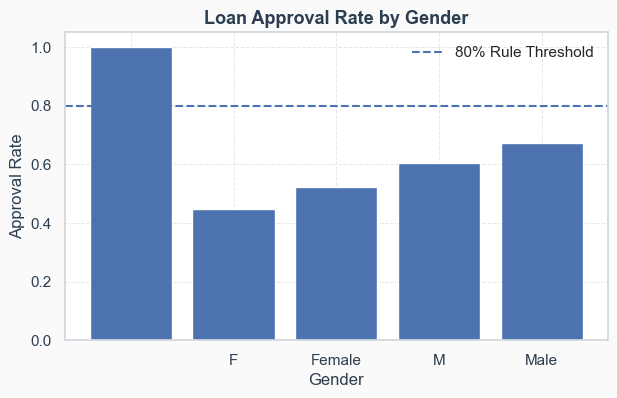

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Extract approval outcome ---
df["approved"] = df["decision"].apply(
    lambda x: x.get("loan_approved") if isinstance(x, dict) else None
)

# --- Extract gender from nested applicant_info ---
df["gender"] = df["applicant_info"].apply(
    lambda x: x.get("gender") if isinstance(x, dict) else None
)

# --- Compute approval statistics by gender ---
approval_stats = df.groupby("gender")["approved"].agg(
    total_applications="count",
    approvals="sum",
    approval_rate="mean"
).reset_index()

# --- Calculate Disparate Impact (80% rule) ---
reference_rate = approval_stats["approval_rate"].max()
approval_stats["disparate_impact_ratio"] = approval_stats["approval_rate"] / reference_rate

# --- Flag potential bias ---
approval_stats["bias_flag"] = approval_stats["disparate_impact_ratio"].apply(
    lambda x: "⚠ Potential Bias" if x < 0.8 else "OK"
)

# --- Display results ---
display(approval_stats)

# --- Visualization ---
plt.figure(figsize=(7,4))

plt.bar(
    approval_stats["gender"],
    approval_stats["approval_rate"]
)

plt.axhline(reference_rate*0.8, linestyle="--", label="80% Rule Threshold")

plt.title("Loan Approval Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Approval Rate")

plt.legend()
plt.show()

The fairness audit compares approval rates across demographic groups. According to the **80% rule**, a disparate impact ratio below 0.8 indicates potential discrimination.
If such patterns appear, the credit decision system should undergo further fairness testing and may require **human oversight mechanisms** under Article 22 of the GDPR and the **EU AI Act high-risk AI system requirements**.

#### We see that the PII filed create privacy, compliance and fairness risks for NovaCred. We have both direct and indirect identifiers in our categories. 
- **Direct identifiers** such as full name, email, and SSN can immediately identify an applicant.
- **Online identifiers** such as IP address are personal data under GDPR and may reveal device or location context.
- **Quasi-identifiers** such as date of birth and ZIP code may not identify someone alone, but can enable re-identification when combined with other fields.
- **Protected attributes** such as gender create additional fairness and discrimination risks in automated credit decisions.

We need to execute a brief deep dive into the SSN, as the sensitivity of it can lead to serious consequences such as financial fraud, or impersonation from outsiders if the data is leaked. We could assume that this conflicts with GDPR data minimization as a machine learning model should not rquire SSN to predict credit worthiness (if not proved otherwise) 

### Section Conclusion

The NovaCred dataset contains several direct and sensitive identifiers (such as names, emails, SSNs, and IP addresses) stored in raw form, which creates significant privacy risks. 
This structure conflicts with core GDPR principles: 
**data minimization (Art. 5(1)(c))**
**integrity and confidentiality (Art. 5(1)(f))**
**storage limitation (Art. 5(1)(e))** (data is exposed without visible protection or retention controls)
Additionally, the presence of automated credit decision variables raises potential concerns under **Article 22**
The dataset in its current form does not fully meet GDPR governance standards and requires stronger privacy safeguards.

# 2 - GDPR Article Mapping 

In [73]:
# --- GDPR mapping and governance risk analysis (readable display) ---

from IPython.display import display, HTML

# Make long text fully visible in Jupyter
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

gdpr_mapping = pd.DataFrame({
    "dataset_issue": [
        "Raw identifiers stored (name, email)",
        "SSN stored in plain text",
        "IP address collected and stored",
        "Demographic attributes present (DOB, gender)",
        "No consent tracking visible",
        "No retention or deletion metadata",
        "Automated credit decisions recorded"
    ],
    
    "relevant_gdpr_article": [
        "Art. 5(1)(c) – Data Minimization",
        "Art. 5(1)(f) – Integrity & Confidentiality",
        "Art. 4(1) – Definition of Personal Data",
        "Art. 5(1)(a), Art. 22 – Fairness & Automated Decisions",
        "Art. 6 – Lawfulness of Processing",
        "Art. 5(1)(e), Art. 17 – Storage Limitation & Right to Erasure",
        "Art. 22 – Automated Decision-Making"
    ],
    
    "why_dangerous": [
        "Direct identifiers allow immediate identification of individuals.",
        "SSNs uniquely identify individuals and are highly sensitive national identifiers.",
        "IP addresses may reveal device, location, or behavioral patterns.",
        "Demographic attributes may introduce discrimination risks in credit decisions.",
        "Absence of consent tracking makes the legal basis of processing unclear.",
        "Lack of retention metadata may lead to indefinite storage of personal data.",
        "Automated credit decisions may affect individuals without meaningful human review."
    ],
    
    "juridical_consequences": [
        "Violation of GDPR data minimization principles and possible regulatory investigation.",
        "Severe GDPR penalties for insufficient protection of sensitive personal identifiers.",
        "Legal classification as personal data requiring appropriate security safeguards.",
        "Potential discrimination claims and regulatory scrutiny of algorithmic fairness.",
        "Unlawful processing under GDPR if no valid legal basis is documented.",
        "Non-compliance with storage limitation and right-to-erasure obligations.",
        "Violation of Article 22 protections regarding automated decision-making."
    ],
    
    "governance_obligation": [
        "Limit collection and exposure of direct identifiers.",
        "Apply pseudonymization or strong encryption controls.",
        "Protect online identifiers and restrict access.",
        "Monitor fairness and prevent discriminatory outcomes.",
        "Document legal basis and consent mechanisms.",
        "Define retention policies and deletion mechanisms.",
        "Implement human oversight for automated decisions."
    ]
})

# Display as styled HTML table with wrapped text
display(
    HTML(
        gdpr_mapping.to_html(index=False).replace(
            '<table border="1" class="dataframe">',
            '<table border="1" class="dataframe" style="width:100%; table-layout:fixed; border-collapse:collapse;">'
        )
    )
)

# Apply notebook-level CSS for readability
display(HTML("""
<style>
table.dataframe td, table.dataframe th {
    white-space: normal !important;
    word-wrap: break-word;
    text-align: left !important;
    vertical-align: top;
    padding: 8px;
}
table.dataframe th {
    background-color: #EAF2F8;
    font-weight: bold;
}
</style>
"""))

dataset_issue,relevant_gdpr_article,why_dangerous,juridical_consequences,governance_obligation
"Raw identifiers stored (name, email)",Art. 5(1)(c) – Data Minimization,Direct identifiers allow immediate identification of individuals.,Violation of GDPR data minimization principles and possible regulatory investigation.,Limit collection and exposure of direct identifiers.
SSN stored in plain text,Art. 5(1)(f) – Integrity & Confidentiality,SSNs uniquely identify individuals and are highly sensitive national identifiers.,Severe GDPR penalties for insufficient protection of sensitive personal identifiers.,Apply pseudonymization or strong encryption controls.
IP address collected and stored,Art. 4(1) – Definition of Personal Data,"IP addresses may reveal device, location, or behavioral patterns.",Legal classification as personal data requiring appropriate security safeguards.,Protect online identifiers and restrict access.
"Demographic attributes present (DOB, gender)","Art. 5(1)(a), Art. 22 – Fairness & Automated Decisions",Demographic attributes may introduce discrimination risks in credit decisions.,Potential discrimination claims and regulatory scrutiny of algorithmic fairness.,Monitor fairness and prevent discriminatory outcomes.
No consent tracking visible,Art. 6 – Lawfulness of Processing,Absence of consent tracking makes the legal basis of processing unclear.,Unlawful processing under GDPR if no valid legal basis is documented.,Document legal basis and consent mechanisms.
No retention or deletion metadata,"Art. 5(1)(e), Art. 17 – Storage Limitation & Right to Erasure",Lack of retention metadata may lead to indefinite storage of personal data.,Non-compliance with storage limitation and right-to-erasure obligations.,Define retention policies and deletion mechanisms.
Automated credit decisions recorded,Art. 22 – Automated Decision-Making,Automated credit decisions may affect individuals without meaningful human review.,Violation of Article 22 protections regarding automated decision-making.,Implement human oversight for automated decisions.


### Data Minimization (GDPR Article 5(1)(c))

Data minimization require that personal data collected and processed be **adequate, relevant and limited** to what is necessary (reletade to the specific purpose). Again we find variables in our dataset that may exceed such purpose. For extent we can question the use of IP adresses regarding relvance for a creditworthiness assesment. Same applies to spending behavior related data, the lifestyle or health related spendings should not be necessary. Additionaly they lead toprivacy risks and sensitive inferences. 
Furthermore, the ZIP code, date of birth and gender, considered as quasi identifiers, create a risk of re-identification. Put togehter they can help uniquely identify individuals (it limits pseudonymization approach). 

In [74]:
# --- Data minimization audit: evidence of excessive personal data collection ---

import pandas as pd

# 1) Presence of IP addresses
ip_non_null = df_flat["applicant_ip_address"].notna().sum()
ip_pct = round(df_flat["applicant_ip_address"].notna().mean() * 100, 2)

# 2) Granular spending behavior categories
# Flatten spending categories from list of dicts
spending_categories = []

for row in df["spending_behavior"].dropna():
    if isinstance(row, list):
        for item in row:
            if isinstance(item, dict) and "category" in item:
                spending_categories.append(item["category"])

spending_series = pd.Series(spending_categories)
category_counts = spending_series.value_counts().reset_index()
category_counts.columns = ["category", "count"]

# Potentially sensitive / lifestyle-related categories
sensitive_categories = [
    "Healthcare",
    "Gambling",
    "Adult Entertainment",
    "Alcohol",
    "Pharmacy"
]

sensitive_found = category_counts[
    category_counts["category"].isin(sensitive_categories)
].copy()

# 3) Re-identification risk from quasi-identifiers
quasi_cols = ["applicant_zip_code", "applicant_date_of_birth", "applicant_gender"]

quasi_df = df_flat[quasi_cols].dropna().copy()
quasi_grouped = (
    quasi_df.groupby(quasi_cols)
    .size()
    .reset_index(name="count")
)

unique_quasi_combos = (quasi_grouped["count"] == 1).sum()
total_quasi_combos = quasi_grouped.shape[0]
unique_quasi_pct = round(unique_quasi_combos / total_quasi_combos * 100, 2) if total_quasi_combos > 0 else 0

# Summary audit table
data_minimization_audit = pd.DataFrame({
    "check": [
        "IP addresses present in dataset",
        "Sensitive / lifestyle spending categories present",
        "Unique combinations of ZIP code + DOB + gender"
    ],
    "evidence": [
        f"{ip_non_null} records ({ip_pct}%) contain IP addresses",
        f"{len(sensitive_found)} sensitive category types detected",
        f"{unique_quasi_combos} unique combinations ({unique_quasi_pct}% of combinations)"
    ],
    "why_it_matters": [
        "IP addresses are personal data and may be unnecessary for creditworthiness assessment",
        "Granular spending categories may reveal sensitive inferences beyond what is necessary",
        "Unique quasi-identifier combinations increase re-identification risk even without direct identifiers"
    ],
    "gdpr_link": [
        "Art. 5(1)(c) – Data minimization",
        "Art. 5(1)(c) – Data minimization",
        "Art. 5(1)(c) + re-identification risk"
    ]
})

display(data_minimization_audit)

print("\nTop spending categories:")
display(category_counts.head(10))

print("\nPotentially sensitive spending categories found:")
display(sensitive_found if not sensitive_found.empty else pd.DataFrame({"message": ["No sensitive categories detected in predefined list"]}))

,check,evidence,why_it_matters,gdpr_link
0,IP addresses present in dataset,497 records (99.6%) contain IP addresses,IP addresses are personal data and may be unnecessary for creditworthiness assessment,Art. 5(1)(c) – Data minimization
1,Sensitive / lifestyle spending categories present,4 sensitive category types detected,Granular spending categories may reveal sensitive inferences beyond what is necessary,Art. 5(1)(c) – Data minimization
2,Unique combinations of ZIP code + DOB + gender,497 unique combinations (99.8% of combinations),Unique quasi-identifier combinations increase re-identification risk even without direct identifiers,Art. 5(1)(c) + re-identification risk



Top spending categories:


,category,count
0,Travel,80
1,Utilities,76
2,Entertainment,72
3,Fitness,71
4,Healthcare,68
5,Insurance,68
6,Dining,66
7,Groceries,65
8,Education,64
9,Transportation,61



Potentially sensitive spending categories found:


,category,count
4,Healthcare,68
12,Alcohol,11
13,Gambling,7
14,Adult Entertainment,5


As mentioned previously some of the contained informations are not relevant to credit worthiness. It also provides sensitive lifestyle inferences that goes beyond stricly necessary. Finally we find quasi identifiers who can used to identify users by combining them. 

### Right to Erasure (GDPR Article 17) 

Right to erasure pushes organisations to have systems in place in which they can locate and delete records that link to a particular individual. 
Still, we identify specific cases. In a system using pseudonymization, simply separating the identifying informations from the dataset is considered sufficient. It would render the dataset anonymous, hence tackling the problem. 
This being said, there are still practical limitations to the right to erasure. We can access data through backup systems and audit logs, those are usually filled with historical copies of data, which are sometimes hard to delete on demand. On another hand, the institutions themselves sometimes have obligation to preserve data in order to legally answer regulations or prove anti-money laundering purposes. 

In practice, this means NovaCred should be able to identify a specific applicant record and remove or anonymize personal identifiers in a controlled and documented way.

The following simulation illustrates how a right-to-erasure request could be handled at the dataset level.

In [70]:
# Select one example applicant record
erasure_demo = df_flat[[
    "_id",
    "applicant_full_name",
    "applicant_email",
    "applicant_ssn",
    "applicant_ip_address",
    "applicant_date_of_birth",
    "applicant_gender",
    "applicant_zip_code"
]].head(1).copy()

# Simulate erasure
erased_record = erasure_demo.copy()

fields_to_erase = [
    "applicant_full_name",
    "applicant_email",
    "applicant_ssn",
    "applicant_ip_address",
    "applicant_date_of_birth",
    "applicant_zip_code"
]

for col in fields_to_erase:
    erased_record[col] = "[ERASED]"

In [71]:
from IPython.display import display, HTML

display(
    HTML(
        f"""
        <div style="display:flex; flex-direction:column; gap:30px">

            <div>
                <h4>Original Record</h4>
                {erasure_demo.to_html(index=False)}
            </div>

            <div>
                <h4>After Erasure Simulation</h4>
                {erased_record.to_html(index=False)}
            </div>

        </div>
        """
    )
)

_id,applicant_full_name,applicant_email,applicant_ssn,applicant_ip_address,applicant_date_of_birth,applicant_gender,applicant_zip_code
app_200,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,2001-03-09,Male,10036
_id,applicant_full_name,applicant_email,applicant_ssn,applicant_ip_address,applicant_date_of_birth,applicant_gender,applicant_zip_code
app_200,[ERASED],[ERASED],[ERASED],[ERASED],[ERASED],Male,[ERASED]


This simulation shows how direct identifiers and quasi-identifiers could be removed from a record in response to a deletion request.

From a governance perspective, the right to erasure requires more than manual deletion in a notebook. NovaCred would need a documented operational process that includes:

- identification of the data subject
- traceability across systems and storage layers
- deletion or anonymization of relevant fields
- retention exceptions where legal obligations require temporary preservation

The current dataset does not contain visible metadata such as deletion status, retention expiry, or erasure logs, which limits auditability of this right in practice.

### Lawful Basis and Automated Decision-Making (GDPR Articles 6 and 22)

In the context of loan evaluation, the appropriate legal basis is Article 6(1)(b), which grants right to processing when necessary for a contract performance (or request the data subject prior to entering contract). This leads to the financial institutions having to collect and analyse personal and financial information with the purpose of understanding wether the applicant qualifies righfully for credit. 
Nonetheless some of thos attributes in our dataset might be consiidered to exceed the strict restrictions mentioned above. If we take a look at Social Security Numbers, it can be justified for purpose of identity verification, but should not remain accessible in the databased once verification is cleared. 
Furthermore, when we look into automated selection processes, we must look at Article 22 of the GDPR. We know that our dataset contains an automated systems which approves/rejects loans. The Article of GDPR provided grants applicants the right to not be judged only by an automated system. This leads organization to provide possibility of human review or mechanism allowing humans to contest decisions. 

Under GDPR Article 22, individuals have protections when decisions are made solely by automated means and those decisions produce legal or similarly significant effects, such as credit approval or rejection.
To assess this risk, we inspect the decision-related fields in the dataset and look for evidence of:
- automated approval / rejection outputs
- algorithmic rejection reasons
- absence of human oversight indicators

In [23]:
# Inspect the decision-related fields
decision_cols = [
    "decision_loan_approved",
    "decision_interest_rate",
    "decision_approved_amount",
    "decision_rejection_reason"
]

df_flat[decision_cols].head(10)

,decision_loan_approved,decision_interest_rate,decision_approved_amount,decision_rejection_reason
0,False,NaN,NaN,algorithm_risk_score
1,False,NaN,NaN,algorithm_risk_score
2,True,3.7,59000.0,NaN
3,True,4.3,34000.0,NaN
4,False,NaN,NaN,algorithm_risk_score
5,False,NaN,NaN,algorithm_risk_score
6,True,5.6,27000.0,NaN
7,True,2.8,38000.0,NaN
8,False,NaN,NaN,algorithm_risk_score
9,False,NaN,NaN,insufficient_credit_history


In [28]:
from IPython.display import display, HTML

# --- Approvals vs rejections ---
decision_summary = (
    df_flat["decision_loan_approved"]
    .value_counts(dropna=False)
    .rename_axis("loan_approved")
    .reset_index(name="count")
)

# --- Rejection reasons ---
rejection_reason_counts = (
    df_flat["decision_rejection_reason"]
    .fillna("No rejection reason")
    .value_counts()
    .reset_index()
)

rejection_reason_counts.columns = ["rejection_reason", "count"]

# --- Potentially automated rejection reasons ---
automated_keywords = ["algorithm", "risk_score", "model", "score", "automated"]

auto_rejections = df_flat[
    df_flat["decision_rejection_reason"]
    .fillna("")
    .str.lower()
    .str.contains("|".join(automated_keywords), regex=True)
]

auto_rejection_sample = auto_rejections[[
    "_id",
    "decision_loan_approved",
    "decision_rejection_reason"
]].head(10)

# --- Display side-by-side ---
display(
    HTML(
        f"""
        <div style="display:flex; gap:40px; align-items:flex-start">

            <div style="width:30%">
                <h4>Approval vs Rejection</h4>
                {decision_summary.to_html(index=False)}
            </div>

            <div style="width:35%">
                <h4>Rejection Reasons</h4>
                {rejection_reason_counts.to_html(index=False)}
            </div>

            <div style="width:35%">
                <h4>Potential Automated Rejections</h4>
                {auto_rejection_sample.to_html(index=False)}
            </div>

        </div>
        """
    )
)

The dataset provides clear evidence that NovaCred stores automated credit decision outputs, including approval status and rejection reasons.

If rejection reasons include terms such as `algorithm_risk_score`, this suggests that some applicants are denied credit through an algorithmic decision rule rather than a documented human review process as we seen previously. 

From a governance perspective, this raises a potential **GDPR Article 22 risk**, since applicants may be subject to decisions with significant legal or financial effects without visible evidence of human intervention, contestability, or explanation.

## 3. Pseudonymization & Anonymization

Under the GDPR, organizations must implement technical and organizational measures to reduce the risk associated with storing personal data.

**GDPR Article 4(5)** defines *pseudonymization* as the processing of personal data in a way that prevents direct attribution to a specific individual without additional information kept separately.

**GDPR Article 32** further recommends pseudonymization and encryption as appropriate safeguards to ensure the security and confidentiality of personal data.

In the NovaCred dataset, several fields contain direct identifiers or sensitive attributes. To reduce privacy risks while preserving analytical usefulness, multiple privacy-preserving techniques can be applied to these fields.

The table below outlines the privacy protection strategies considered for different categories of personal data present in the dataset.

First lets identify whether our dataset applies privacy preserving techniques consistently. For it, we want to check if they appear as raw readable form or pseudonymised. We will treat as not pseudonymised names, emails, SSN, or IP addresses that can be directly interpretable. 

In [68]:
df_flat["applicant_ip_pseudo"] = df_flat["applicant_ip_address"].apply(pseudonymize)

In [69]:
import re
import pandas as pd

# --- Pattern-based checks for raw identifiers ---
email_pattern = r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$"
ssn_pattern = r"^\d{3}-\d{2}-\d{4}$"
ip_pattern = r"^\d{1,3}(\.\d{1,3}){3}$"

# Columns to audit
privacy_audit_cols = [
    "applicant_full_name",
    "applicant_email",
    "applicant_ssn",
    "applicant_ip_address",
    "applicant_name_pseudo",
    "applicant_email_pseudo",
    "applicant_ssn_pseudo",
    "applicant_ip_pseudo"
]

audit_results = []

for col in privacy_audit_cols:
    if col not in df_flat.columns:
        continue

    series = df_flat[col].dropna().astype(str)

    if col == "applicant_full_name":
        raw_matches = series.str.contains(r"[A-Za-z]+\s+[A-Za-z]+", regex=True).sum()
        status = "Not pseudonymized" if raw_matches > 0 else "Possibly pseudonymized"

    elif col == "applicant_email":
        raw_matches = series.str.match(email_pattern).sum()
        status = "Not pseudonymized" if raw_matches > 0 else "Possibly pseudonymized"

    elif col == "applicant_ssn":
        raw_matches = series.str.match(ssn_pattern).sum()
        status = "Not pseudonymized" if raw_matches > 0 else "Possibly pseudonymized"

    elif col == "applicant_ip_address":
        raw_matches = series.str.match(ip_pattern).sum()
        status = "Not pseudonymized" if raw_matches > 0 else "Possibly pseudonymized"

    else:
        # Pseudonymized columns: check if values look hashed
        raw_matches = series.str.match(r"^[a-f0-9]{16,64}$").sum()
        status = "Pseudonymized" if raw_matches > 0 else "Not clearly pseudonymized"

    audit_results.append({
        "column_name": col,
        "non_null_values": int(series.shape[0]),
        "matching_identifier_pattern": int(raw_matches),
        "status": status
    })

pseudonymization_audit = pd.DataFrame(audit_results)

def highlight_status(val):
    if val == "Not pseudonymized":
        return "background-color:#F8D7DA; color:#721C24; font-weight:bold;"
    elif val == "Pseudonymized":
        return "background-color:#D1E7DD; color:#0F5132; font-weight:bold;"
    elif "Possibly" in val:
        return "background-color:#FFF3CD; color:#664D03;"
    else:
        return "background-color:#FDE2C8; color:#7C2D12;"

pseudonymization_audit.style.applymap(highlight_status, subset=["status"])

/var/folders/6x/48zsnbjs4hz2kb565wlpx3800000gn/T/ipykernel_17573/1531304163.py:69: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  pseudonymization_audit.style.applymap(highlight_status, subset=["status"])


,column_name,non_null_values,matching_identifier_pattern,status
0,applicant_full_name,499,499,Not pseudonymized
1,applicant_email,499,490,Not pseudonymized
2,applicant_ssn,497,497,Not pseudonymized
3,applicant_ip_address,497,497,Not pseudonymized
4,applicant_name_pseudo,499,499,Pseudonymized
5,applicant_email_pseudo,499,499,Pseudonymized
6,applicant_ssn_pseudo,497,497,Pseudonymized
7,applicant_ip_pseudo,497,497,Pseudonymized


The audit confirms highly sensitive fiels are still in directly readable format. This concerns applicants names, emails, SSns and IP addresses. We will hereafter see how it should look like to be compliant using hashed columns for all the direct identifiers still present. We want to go from the Red status to the green one. 

In [67]:
# --- Pseudonymization of sensitive identifiers ---

import hashlib

def pseudonymize(value):
    """
    Convert a personal identifier into a pseudonymized hash using SHA-256.
    """
    if pd.isna(value):
        return None

    value_str = str(value)
    hashed_value = hashlib.sha256(value_str.encode()).hexdigest()[:16]  # shortened for readability
    
    return hashed_value


# Create pseudonymized columns
df_flat["applicant_name_pseudo"] = df_flat["applicant_full_name"].apply(pseudonymize)
df_flat["applicant_email_pseudo"] = df_flat["applicant_email"].apply(pseudonymize)
df_flat["applicant_ssn_pseudo"] = df_flat["applicant_ssn"].apply(pseudonymize)
df_flat["applicant_ip_pseudo"] = df_flat["applicant_ip_address"].apply(pseudonymize)


# Display comparison of original vs pseudonymized identifiers
df_flat[
    [
        "applicant_full_name",
        "applicant_name_pseudo",
        "applicant_email",
        "applicant_email_pseudo",
        "applicant_ssn",
        "applicant_ssn_pseudo",
        "applicant_ip_address",
        "applicant_ip_pseudo"
    ]
].head(10)

,applicant_full_name,applicant_name_pseudo,applicant_email,applicant_email_pseudo,applicant_ssn,applicant_ssn_pseudo,applicant_ip_address,applicant_ip_pseudo
0,Jerry Smith,68ee17cf46b05603,jerry.smith17@hotmail.com,116648a776152574,596-64-4340,2caf30528c21a10e,192.168.48.155,afb811b70bdc95ef
1,Brandon Walker,4c539f3c4c8794d5,brandon.walker2@yahoo.com,c3522c0b54ef9045,425-69-4784,2f7da45fefdcfb2c,10.1.102.112,f661245c5f3728b2
2,Scott Moore,4ad1a6eb65ea2135,scott.moore94@mail.com,b299e7d6a37e183b,370-78-5178,db120edcee2366a4,10.240.193.250,21d90a6a0acf547b
3,Thomas Lee,0b6a308e6a3e28e0,thomas.lee6@protonmail.com,6fbd2478748a29fa,194-35-1833,c835719be0201898,192.168.175.67,d30e2d3de6bbb8b7
4,Brian Rodriguez,099b981258dca619,brian.rodriguez86@aol.com,f24e7cc1450ee9aa,480-41-2475,41c7de40dc491858,172.29.125.105,634f13527ff85686
5,Maria Miller,e000c1c9876a7cda,maria.miller67@outlook.com,8843b2c0ec23996a,417-25-4912,a0a5f9cec1ea52aa,172.25.58.70,e3cce14c00bca273
6,Nicholas King,52f245abedecbea4,nicholas.king46@outlook.com,03c1a6e2b0058c37,613-23-2503,51280b2e354d80c6,10.62.62.45,c20a53f2b18e1c6b
7,Susan Rivera,de7677e8bcad5409,susan.rivera74@gmail.com,67c6d13632c3404f,176-97-1864,04adc2ff16245195,192.168.158.59,762fcfcbb83d8e99
8,Joseph Lopez,750c74fb22b712d1,joseph.lopez1@gmail.com,a7f7177878859512,652-70-5530,fb789d550e179a5c,192.168.91.142,e643564e0802416e
9,Michael Mitchell,dcb77bc29d159f43,michael.mitchell42@hotmail.com,f6a2496402be6666,100-94-8400,0befb0709774eeb4,172.28.12.121,6655b9f9b2964cdc


The table above demonstrates pseudonymization applied to the most sensitive direct identifiers in the dataset: applicant name, email, and SSN.

Each value is transformed using SHA-256 hashing, producing a consistent pseudonymous identifier that prevents direct identification while preserving the ability to link records internally.

This approach supports GDPR principles of **data minimization (Art. 5(1)(c))** and **security of processing (Art. 32)** by reducing the exposure of raw identifiers in analytical environments.

This simulation shows how direct identifiers and quasi-identifiers could be removed from a record in response to a deletion request.

From a governance perspective, the right to erasure requires more than manual deletion in a notebook. NovaCred would need a documented operational process that includes:

- identification of the data subject
- traceability across systems and storage layers
- deletion or anonymization of relevant fields
- retention exceptions where legal obligations require temporary preservation

The current dataset does not contain visible metadata such as deletion status, retention expiry, or erasure logs, which limits auditability of this right in practice.

## 5. EU AI Act Classification

Under the EU AI Act, certain AI systems are classified as **High-Risk** when they significantly affect individuals' access to essential services.

Credit scoring and creditworthiness assessments fall into this category because they influence a person's ability to obtain financial services.

The NovaCred system processes applicant financial and behavioral data to determine whether a loan should be approved or rejected. As a result, the system qualifies as a **High-Risk AI System** under the EU AI Act.

High-risk AI systems must comply with strict requirements related to risk management, transparency, data governance, and human oversight.

In [76]:
# --- EU AI Act risk classification for the NovaCred system ---

ai_act_classification = pd.DataFrame({

"system_component": [
"Automated loan approval decision",
"Use of demographic attributes (gender, age)",
"Storage of personal identifiers",
"Behavioral spending analysis",
"Credit scoring algorithm"
],

"ai_act_risk_category": [
"High Risk",
"High Risk",
"High Risk",
"High Risk",
"High Risk"
],

"regulatory_reference": [
"EU AI Act – Annex III (Access to essential services)",
"EU AI Act – Art. 10 & fairness obligations",
"EU AI Act – Art. 10 (Data governance)",
"EU AI Act – Annex III (profiling in financial services)",
"EU AI Act – Annex III (creditworthiness evaluation)"
],

"reason": [
"Affects access to financial services",
"Potential discrimination in automated decisions",
"Processing of personal data in decision systems",
"Behavioral profiling influencing financial eligibility",
"Automated evaluation of creditworthiness"
],

"required_controls": [
"Human oversight and contestability mechanisms",
"Fairness testing and bias monitoring",
"Strong data governance and privacy protection",
"Transparency of decision logic",
"Risk management and continuous monitoring"
]

})

# --- Styling for risk level ---

def highlight_risk(val):
    if val == "High Risk":
        return "background-color:#F8D7DA; color:#721C24; font-weight:bold;"
    elif val == "Limited Risk":
        return "background-color:#FFF3CD; color:#664D03;"
    elif val == "Minimal Risk":
        return "background-color:#D1E7DD; color:#0F5132;"
    else:
        return ""

ai_act_classification.style.applymap(
    highlight_risk,
    subset=["ai_act_risk_category"]
)

/var/folders/6x/48zsnbjs4hz2kb565wlpx3800000gn/T/ipykernel_17573/4038512691.py:59: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  ai_act_classification.style.applymap(


,system_component,ai_act_risk_category,regulatory_reference,reason,required_controls
0,Automated loan approval decision,High Risk,EU AI Act – Annex III (Access to essential services),Affects access to financial services,Human oversight and contestability mechanisms
1,"Use of demographic attributes (gender, age)",High Risk,EU AI Act – Art. 10 & fairness obligations,Potential discrimination in automated decisions,Fairness testing and bias monitoring
2,Storage of personal identifiers,High Risk,EU AI Act – Art. 10 (Data governance),Processing of personal data in decision systems,Strong data governance and privacy protection
3,Behavioral spending analysis,High Risk,EU AI Act – Annex III (profiling in financial services),Behavioral profiling influencing financial eligibility,Transparency of decision logic
4,Credit scoring algorithm,High Risk,EU AI Act – Annex III (creditworthiness evaluation),Automated evaluation of creditworthiness,Risk management and continuous monitoring


The analysis confirms that NovaCred's credit decision system falls within the High-Risk AI category defined by the EU AI Act as it performs automated creditworthiness assessments which ultimately affect individuals' access to fiancial services. The system components listed the the above table fall under Annex III of the EU AI act. 

This classification makes it that the system must comply with governance requirements which include: 
- implementation of a formal **risk management system**
- **documentation of model logic and training data**
- **human oversight mechanisms** for automated decisions
- monitoring of **bias and discriminatory outcomes**
- maintaining **audit logs and traceability**

These requirements complement existing GDPR obligations, particularly those related to automated decision-making under Article 22. Our dataset analysis reveals that many of the listed safegaurds are not documented or explicitly implemented. 

## 6. Governance & Oversight Controls

The previous analysis identified several privacy, fairness, and regulatory risks in the NovaCred dataset and decision process. To address these risks, NovaCred should implement a set of governance and oversight controls aligned with both GDPR requirements and the EU AI Act obligations for high-risk systems.The table below summarizes recommended governance controls and their expected impact on regulatory compliance.

In [41]:
governance_controls = pd.DataFrame({
    "risk_area": [
        "Personal data exposure",
        "Sensitive identifiers",
        "Automated credit decisions",
        "Bias and discrimination risk",
        "Data retention",
        "Consent and lawful basis",
        "Model transparency"
    ],
    
    "identified_issue": [
        "Direct identifiers stored in dataset",
        "SSN and email visible in raw form",
        "Loan decisions appear fully automated",
        "Demographic attributes present",
        "No retention or deletion metadata",
        "Consent status not recorded",
        "Decision logic not documented"
    ],
    
    "recommended_control": [
        "Apply pseudonymization before analytics access",
        "Encrypt identifiers and restrict access",
        "Implement human review for rejected applications",
        "Monitor fairness metrics and disparate impact",
        "Define retention and deletion policies",
        "Record lawful basis for data processing",
        "Provide explainability for credit decisions"
    ],
    
    "regulatory_basis": [
        "GDPR Art.5(1)(c), Art.32",
        "GDPR Art.32",
        "GDPR Art.22",
        "GDPR Art.5(1)(a), AI Act Art.10",
        "GDPR Art.5(1)(e), Art.17",
        "GDPR Art.6",
        "AI Act transparency requirements"
    ]
})

governance_controls

,risk_area,identified_issue,recommended_control,regulatory_basis
0,Personal data exposure,Direct identifiers stored in dataset,Apply pseudonymization before analytics access,"GDPR Art.5(1)(c), Art.32"
1,Sensitive identifiers,SSN and email visible in raw form,Encrypt identifiers and restrict access,GDPR Art.32
2,Automated credit decisions,Loan decisions appear fully automated,Implement human review for rejected applications,GDPR Art.22
3,Bias and discrimination risk,Demographic attributes present,Monitor fairness metrics and disparate impact,"GDPR Art.5(1)(a), AI Act Art.10"
4,Data retention,No retention or deletion metadata,Define retention and deletion policies,"GDPR Art.5(1)(e), Art.17"
5,Consent and lawful basis,Consent status not recorded,Record lawful basis for data processing,GDPR Art.6
6,Model transparency,Decision logic not documented,Provide explainability for credit decisions,AI Act transparency requirements


In [42]:
governance_maturity = pd.DataFrame({
    "control_category": [
        "Data protection",
        "Privacy engineering",
        "Model governance",
        "Fairness monitoring",
        "Regulatory documentation"
    ],
    
    "current_state": [
        "Basic dataset with visible identifiers",
        "Limited pseudonymization",
        "Automated decision pipeline",
        "Bias analysis performed but not operationalized",
        "No visible compliance documentation"
    ],
    
    "target_state": [
        "Pseudonymized analytical dataset",
        "Encryption and key management",
        "Human oversight and explainability",
        "Continuous fairness monitoring",
        "Documented AI risk management process"
    ]
})

governance_maturity

,control_category,current_state,target_state
0,Data protection,Basic dataset with visible identifiers,Pseudonymized analytical dataset
1,Privacy engineering,Limited pseudonymization,Encryption and key management
2,Model governance,Automated decision pipeline,Human oversight and explainability
3,Fairness monitoring,Bias analysis performed but not operationalized,Continuous fairness monitoring
4,Regulatory documentation,No visible compliance documentation,Documented AI risk management process


Overall we notice that there are multiple important gap present in the dataset. When it comes to AI deplyement we considered it is not yet done in a responsible maner. We can identify formal risk management, clear human oversight mechanisms, transparency toward applicants, and comprehensive audit logging that are not easily or fully visible in the documentation. On another hand we note that some are partially addressed through bias analyses and data quality checks. We raise concerns towards the monitoring structure and decision traceability when it comes to accountability and regulatory compliance. 
NovaCred system is requiring operational safeguard and governance frameworks in order to align with GDPR obligations and EU AI Act requirements as we highlighted many high risk AI systems. 

## Conclusion

This notebook evaluated the NovaCred credit application dataset from a data governance and privacy perspective.The analysis identified several key risks, including the presence of direct personal identifiers, automated credit decision processes, and limited governance metadata.Through pseudonymization techniques, GDPR mapping, and governance recommendations, the analysis demonstrates how privacy and regulatory compliance can be strengthened while preserving analytical value. Future improvements should focus on implementing operational governance controls, including fairness monitoring, retention management, and AI system oversight.